### Lecture et parsing du fichier cowrie de logs SSH → DataFrame

In [75]:
import json
import pandas as pd

path = "../ml/data/cowrie.json"

rows = []

with open(path, "r", encoding="utf-8", errors="ignore") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        try:
            rows.append(json.loads(line))
        except:
            continue

# DataFrame brut
df_ssh = pd.DataFrame(rows)

print("📊 Total events:", len(df_ssh))

# 🎯 Garder seulement les events utiles
VALID_EVENTS = [
    "cowrie.login.failed",
    "cowrie.login.success",
    "cowrie.command.input"
]

df_ssh = df_ssh[df_ssh["eventid"].isin(VALID_EVENTS)]

print("✅ After filtering events:", len(df_ssh))

# 🎯 Nettoyage commandes vides
df_ssh["input"] = df_ssh["input"].fillna("")
df_ssh = df_ssh[
    (df_ssh["eventid"] != "cowrie.command.input") |
    (df_ssh["input"].str.strip().str.len() > 1)
]

# 🎯 Remplir colonnes utiles
df_ssh["username"] = df_ssh["username"].fillna("unknown")
df_ssh["src_ip"] = df_ssh.get("src_ip", "").fillna("unknown")

# 🎯 Reset index propre
df_ssh = df_ssh.reset_index(drop=True)

# 🎯 Aperçu propre
df_ssh[["eventid", "username", "input", "src_ip"]]

📊 Total events: 600
✅ After filtering events: 600


,eventid,username,input,src_ip
0,cowrie.login.success,guest,pwd,172.30.0.23
1,cowrie.command.input,admin,ls,172.30.0.92
2,cowrie.command.input,root,echo hello,172.30.0.49
3,cowrie.command.input,test,ls,172.30.0.77
4,cowrie.login.success,test,whoami,172.30.0.123
...,...,...,...,...
595,cowrie.command.input,test,cat /etc/passwd,172.30.0.161
596,cowrie.command.input,test,uname -a,172.30.0.48
597,cowrie.command.input,admin,uname -a,172.30.0.146
598,cowrie.login.failed,admin,,172.30.0.52


### Graphiques SSH (eventid, commandes)

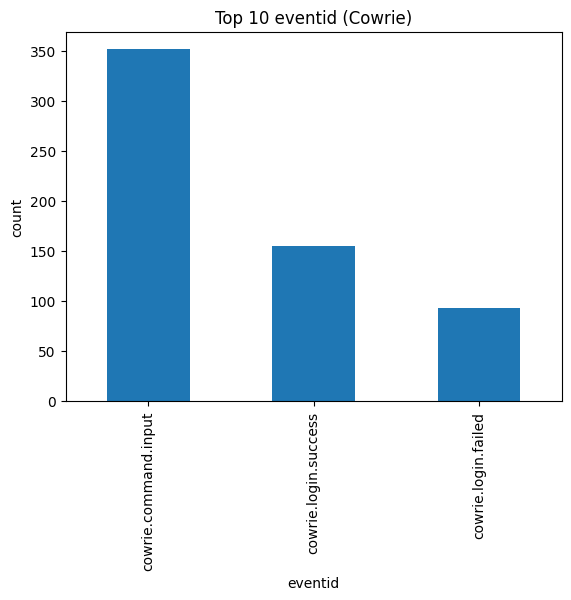

In [76]:
import matplotlib.pyplot as plt

df_ssh["eventid"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 eventid (Cowrie)")
plt.xlabel("eventid")
plt.ylabel("count")
plt.show()

### Commandes (cowrie.command.input) 

In [77]:
cmds = df_ssh[df_ssh["eventid"] == "cowrie.command.input"]["input"].dropna()
cmds.head(20)

1             ls
2     echo hello
3             ls
6     echo hello
7     echo hello
9         whoami
11    echo hello
14           pwd
20        whoami
21           pwd
24        whoami
27            ls
30        whoami
32        whoami
35        whoami
36           pwd
40            ls
42        whoami
43    echo hello
46           pwd
Name: input, dtype: object

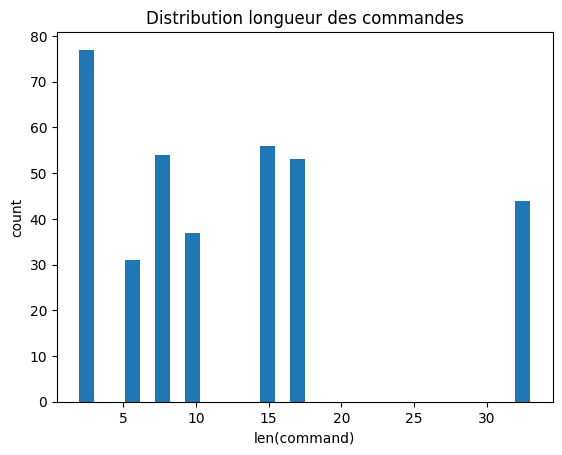

In [78]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()

### Histogramme longueur commandes 

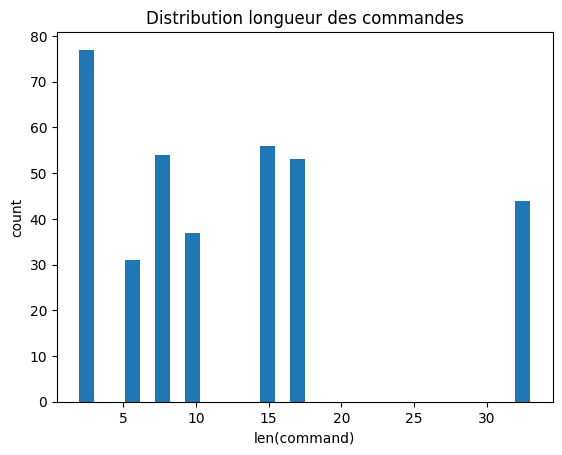

In [66]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()

### Score du Modèle

In [68]:
import sys
sys.path.append("../ml")

import joblib
import numpy as np
from feature_extraction import featurize_ssh_cowrie

### Distribution des scores SSH

In [79]:
import numpy as np
import joblib

# Charger modèle
model_ssh = joblib.load("../ml/model_ssh.joblib")

# ⚠️ Utiliser df_ssh filtré
X_ssh = np.array([
    featurize_ssh_cowrie(row.to_dict(), fails_60s=0)
    for _, row in df_ssh.iterrows()
], dtype=float)

# Prédictions
scores_ssh = model_ssh.score_samples(X_ssh)
preds_ssh = model_ssh.predict(X_ssh)

# Ajouter au dataframe
df_ssh["ml_score"] = scores_ssh
df_ssh["ml_pred"] = preds_ssh

df_ssh.head()

,timestamp,eventid,src_ip,username,input,password,ml_score,ml_pred
0,2026-03-24T21:42:41.965498Z,cowrie.login.success,172.30.0.23,guest,pwd,NaN,-0.526798,1
1,2026-03-24T21:42:42.196592Z,cowrie.command.input,172.30.0.92,admin,ls,NaN,-0.506949,1
2,2026-03-24T21:42:42.383360Z,cowrie.command.input,172.30.0.49,root,echo hello,NaN,-0.545773,1
3,2026-03-24T21:42:42.571283Z,cowrie.command.input,172.30.0.77,test,ls,NaN,-0.502588,1
4,2026-03-24T21:42:42.648460Z,cowrie.login.success,172.30.0.123,test,whoami,NaN,-0.575028,1


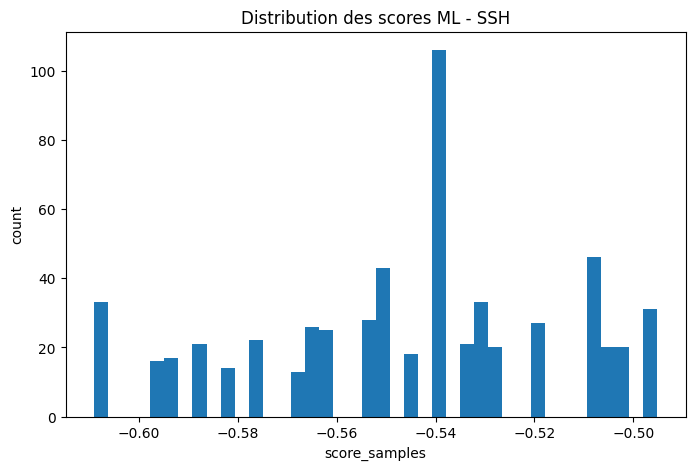

In [80]:
plt.figure(figsize=(8,5))
plt.hist(df_ssh["ml_score"], bins=40)
plt.title("Distribution des scores ML - SSH")
plt.xlabel("score_samples")
plt.ylabel("count")
plt.show()

### Top Anomalie SSH

In [81]:
anomalies_ssh = df_ssh[df_ssh["ml_pred"] == -1].copy()
anomalies_ssh = anomalies_ssh.sort_values("ml_score")

anomalies_ssh[["eventid", "username", "input", "ml_score"]].head(10)

,eventid,username,input,ml_score
17,cowrie.login.success,test,echo hello,-0.609127
66,cowrie.login.success,root,echo hello,-0.609127
81,cowrie.login.success,root,echo hello,-0.609127
91,cowrie.login.success,test,echo hello,-0.609127
101,cowrie.login.success,test,echo hello,-0.609127
118,cowrie.login.success,test,echo hello,-0.609127
135,cowrie.login.success,root,echo hello,-0.609127
162,cowrie.login.success,root,echo hello,-0.609127
165,cowrie.login.success,root,echo hello,-0.609127
169,cowrie.login.success,test,echo hello,-0.609127


### Affichage le taux d’anomalie SSH

In [82]:
(len(df_ssh[df_ssh["ml_pred"] == -1]) / len(df_ssh)) * 100

5.5

In [83]:
print("SSH anomalies:", round((df_ssh["ml_pred"] == -1).mean() * 100, 2), "%")


SSH anomalies: 5.5 %


### Graphiques SSH (eventid, commandes)


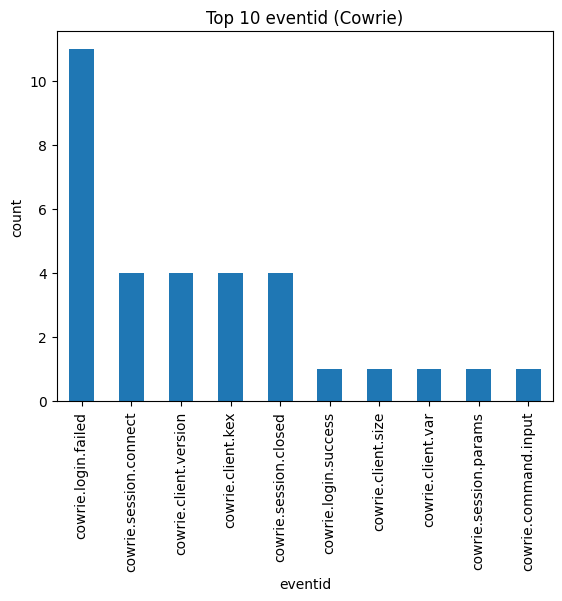

In [12]:
import matplotlib.pyplot as plt

df_ssh["eventid"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 eventid (Cowrie)")
plt.xlabel("eventid")
plt.ylabel("count")
plt.show()

In [11]:
cmds = df_ssh[df_ssh["eventid"] == "cowrie.command.input"]["input"].dropna()
cmds.head(20)

31    cat /etc/passwd
32                 id
33             whoami
34           uname -a
35                 id
56                 ls
58                pwd
59                 ls
60                pwd
61                pwd
65                pwd
69             whoami
70                 ls
71                pwd
73                pwd
74                 ls
75         echo hello
80             whoami
81                 ls
82                pwd
Name: input, dtype: object

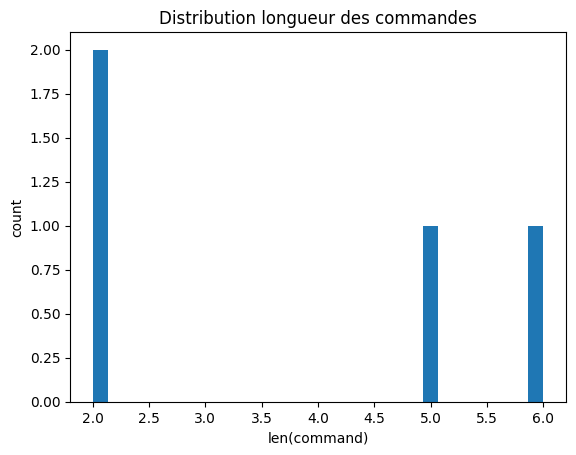

In [4]:
cmd_len = cmds.astype(str).str.len()

cmd_len.plot(kind="hist", bins=30)
plt.title("Distribution longueur des commandes")
plt.xlabel("len(command)")
plt.ylabel("count")
plt.show()